In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
dataset_url = "https://raw.githubusercontent.com/mrc03/IBM-HR-Analytics-Employee-Attrition-Performance/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(dataset_url)

In [4]:
df.isnull().sum().sum()
df.duplicated().sum()

np.int64(0)

In [5]:
print(f"{df.shape[0]} Rows, {df.shape[1]} Columns")

zero_info_cols = [col for col in df.columns if df[col].nunique() == 1 or col == 'EmployeeNumber']
df.drop(columns=zero_info_cols, inplace=True)
print(f" {df.shape[0]} Rows, {df.shape[1]} Columns")

counts = df['Attrition'].value_counts()
pcts = df['Attrition'].value_counts(normalize=True) * 100
for idx in counts.index:
    print(f"Class '{idx}': {counts[idx]} instances ({pcts[idx]:.2f}%)")

1470 Rows, 35 Columns
 1470 Rows, 31 Columns
Class 'No': 1233 instances (83.88%)
Class 'Yes': 237 instances (16.12%)


In [6]:
zero_info_cols

['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

# 2


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15116\613408083.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Attrition', y='MonthlyIncome', palette='mako')


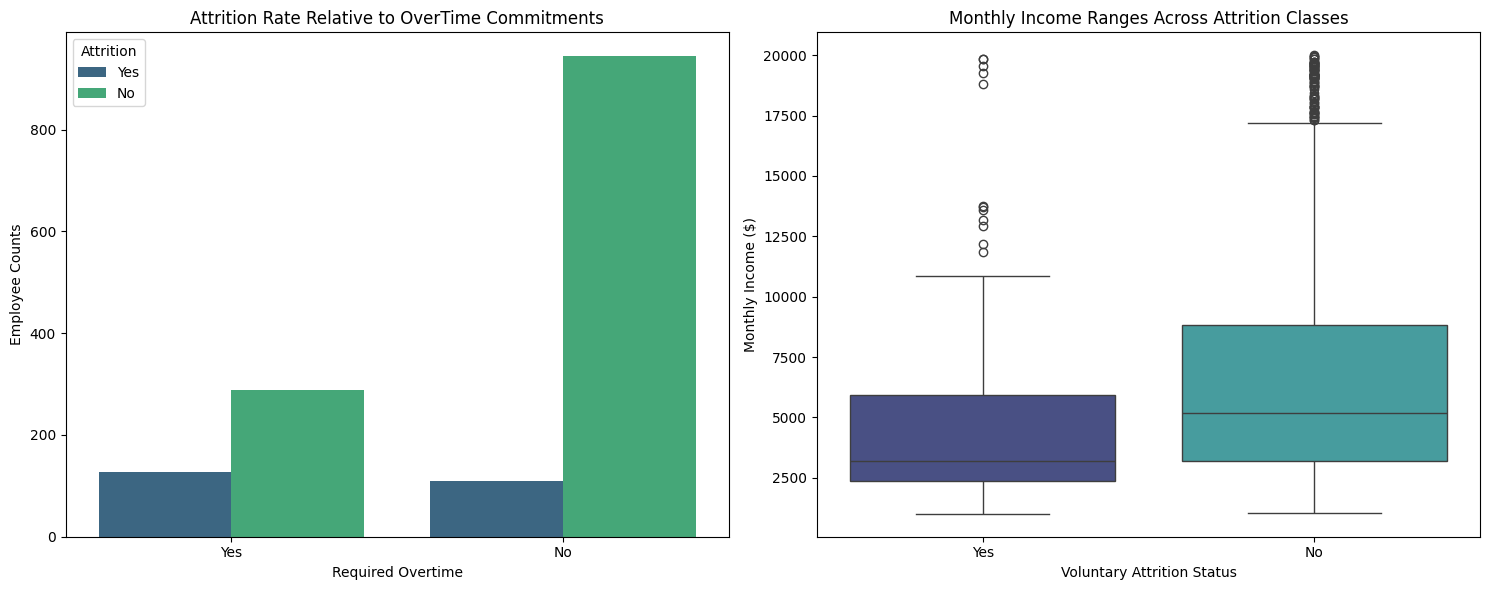

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Attrition vs OverTime Commitment
sns.countplot(ax=axes[0], data=df, x='OverTime', hue='Attrition', palette='viridis')
axes[0].set_title('Attrition Rate Relative to OverTime Commitments')
axes[0].set_xlabel('Required Overtime')
axes[0].set_ylabel('Employee Counts')

# Plot B: Income Distributions against Attrition Status
sns.boxplot(ax=axes[1], data=df, x='Attrition', y='MonthlyIncome', palette='mako')
axes[1].set_title('Monthly Income Ranges Across Attrition Classes')
axes[1].set_xlabel('Voluntary Attrition Status')
axes[1].set_ylabel('Monthly Income ($)')

plt.tight_layout()
plt.show()

# 3

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
X = df.drop(columns=["Attrition"])
y = df["Attrition"]
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15116\761723296.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [21]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap Train set outliers
    X_train[col] = np.where(X_train[col] < lower_bound, lower_bound, X_train[col])
    X_train[col] = np.where(X_train[col] > upper_bound, upper_bound, X_train[col])

    # Cap Test set outliers using Train bounds
    X_test[col] = np.where(X_test[col] < lower_bound, lower_bound, X_test[col])
    X_test[col] = np.where(X_test[col] > upper_bound, upper_bound, X_test[col])

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ]
)

preprocessing_pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

preprocessor.set_output(transform="pandas")
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

# 5

In [28]:
filter_selector = SelectKBest(score_func=f_classif, k=15)
filter_selector.fit(X_train_scaled, y_train)
filter_set = set(X_train_scaled.columns[filter_selector.get_support()])

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [29]:
rfe_selector = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=15)
rfe_selector.fit(X_train_scaled, y_train)
wrapper_set = set(X_train_scaled.columns[rfe_selector.get_support()])

In [30]:
final_features = list(filter_set & wrapper_set)

In [32]:
X_train_final = X_train_scaled[final_features]
X_test_final = X_test_scaled[final_features]

# 6

In [33]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

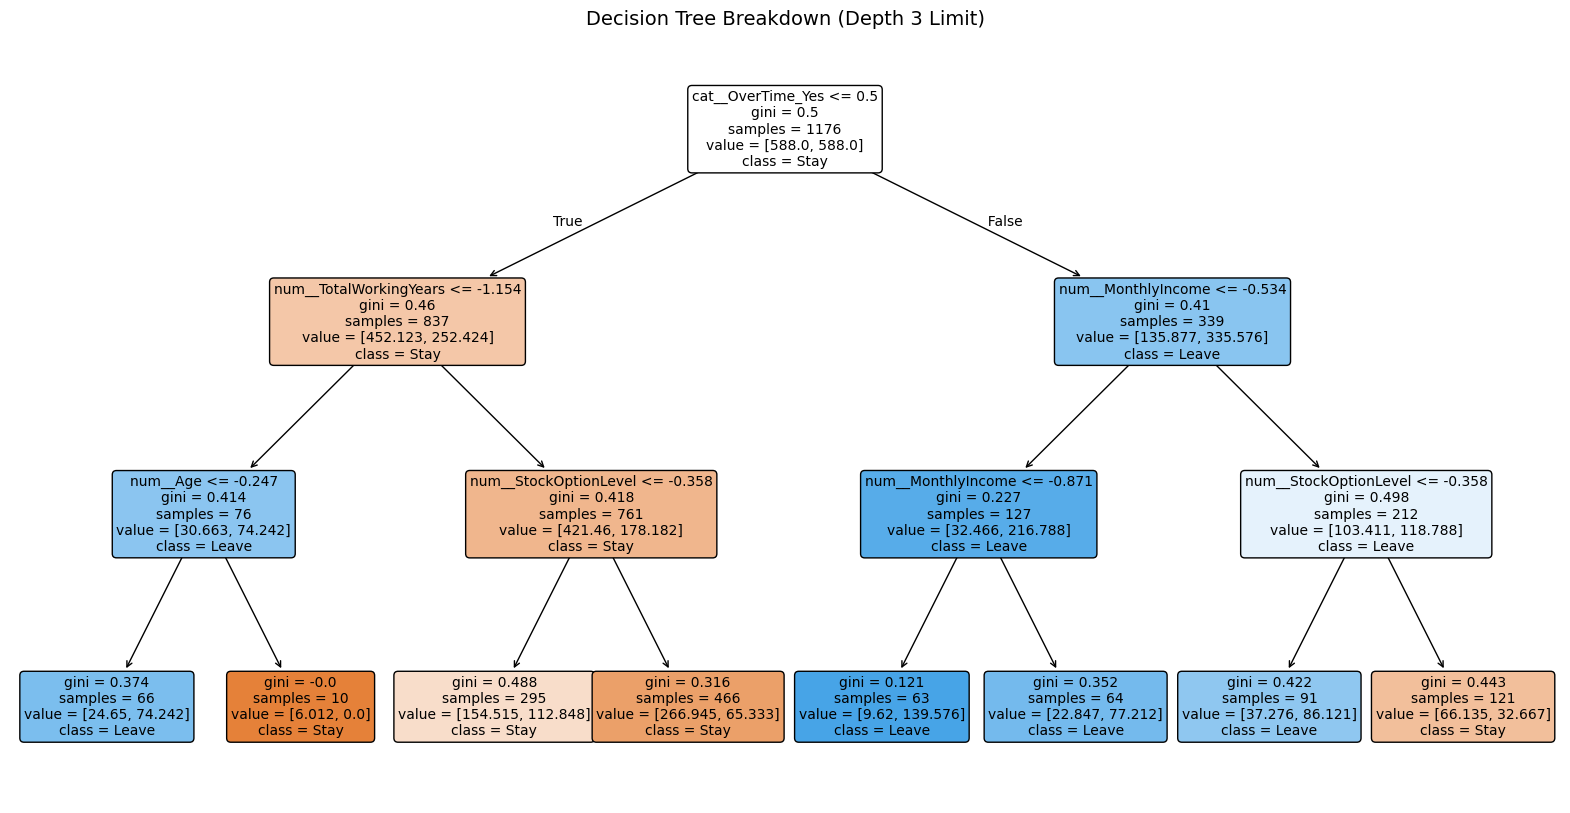

In [34]:
dt_viz = DecisionTreeClassifier(
    random_state=42, max_depth=3, class_weight="balanced"
)
dt_viz.fit(X_train_final, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    dt_viz,
    feature_names=final_features,
    class_names=["Stay", "Leave"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Breakdown (Depth 3 Limit)", fontsize=14)
plt.show()

In [36]:
for name, model in models.items():
    model.fit(X_train_final, y_train)
    preds = model.predict(X_test_final)
    probs = model.predict_proba(X_test_final)[:, 1]

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
results_data = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_final, y_train)
    preds = model.predict(X_test_final)
    probs = model.predict_proba(X_test_final)[:, 1]
    
    # Stratified 5-Fold Cross Validation
    cv_scores = cross_validate(model, X_train_final, y_train, cv=5, scoring='f1')
    
    results_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds),
        'F1-Test': f1_score(y_test, preds),
        'CV-F1-Mean': np.mean(cv_scores),
        'CV-F1-Std': np.std(cv_scores),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })
    
    # Plot ROC Curves collectively
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend()
plt.show()

# Display Performance Matrix DataFrame
df_results = pd.DataFrame(results_data)
import csv # Just for safe display rendering
print(df_results.to_string(index=False))

d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:956: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 945, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\utils\validation.py", line 80, in inner_f
    return f(*args, **kwargs)
  File "d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 322, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\CODING\MACHINE LEARNING\.venv\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
        estim